In [1]:
!pip install jupyter ipykernel pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path / "src") not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import pump_sensors
from data import load_all_datasets
from evaluation import evaluate_logistic_regression_experiment

In [3]:
data_path = "../../data/processed/data_11-03_10-04/"

train_dict, test_severe_dict, test_small_dict = load_all_datasets(data_path)

print(train_dict.keys())
print(test_severe_dict.keys())
print(test_small_dict.keys())

dict_keys([1, 2, 3, 5, 8, 12, 13, 14, 15])
dict_keys(['16_F1', '16_F2', '16_F3', '16_F4', '17_F1', '17_F2', '17_F3', '17_F4'])
dict_keys(['16_F1', '16_F2', '16_F3', '16_F4', '17_F1', '17_F2', '17_F3', '17_F4'])


In [4]:
test_sets = {
    "severe": test_severe_dict,
    "small": test_small_dict,
}

clean_train_df = pd.concat(
    train_dict.values(),
    axis=0
)

feature_cols = [
    col for col in pump_sensors
    if col != "LS-901"
]

all_results = []

for train_severity, train_aug_dict in test_sets.items():
    for train_id, train_aug_df in train_aug_dict.items():

        train_df = pd.concat(
            [clean_train_df, train_aug_df],
            axis=0
        )

        for test_severity, test_dict in test_sets.items():
            for test_id, test_df in test_dict.items():

                if train_id == test_id:
                    continue

                metrics, results_df, model = evaluate_logistic_regression_experiment(
                    train_df=train_df,
                    test_df=test_df,
                    feature_cols=feature_cols,
                    threshold=0.5
                )

                all_results.append({
                    "train_session": train_id,
                    "train_severity": train_severity,
                    "test_session": test_id,
                    "test_severity": test_severity,
                    **metrics
                })

results_table = pd.DataFrame(all_results)

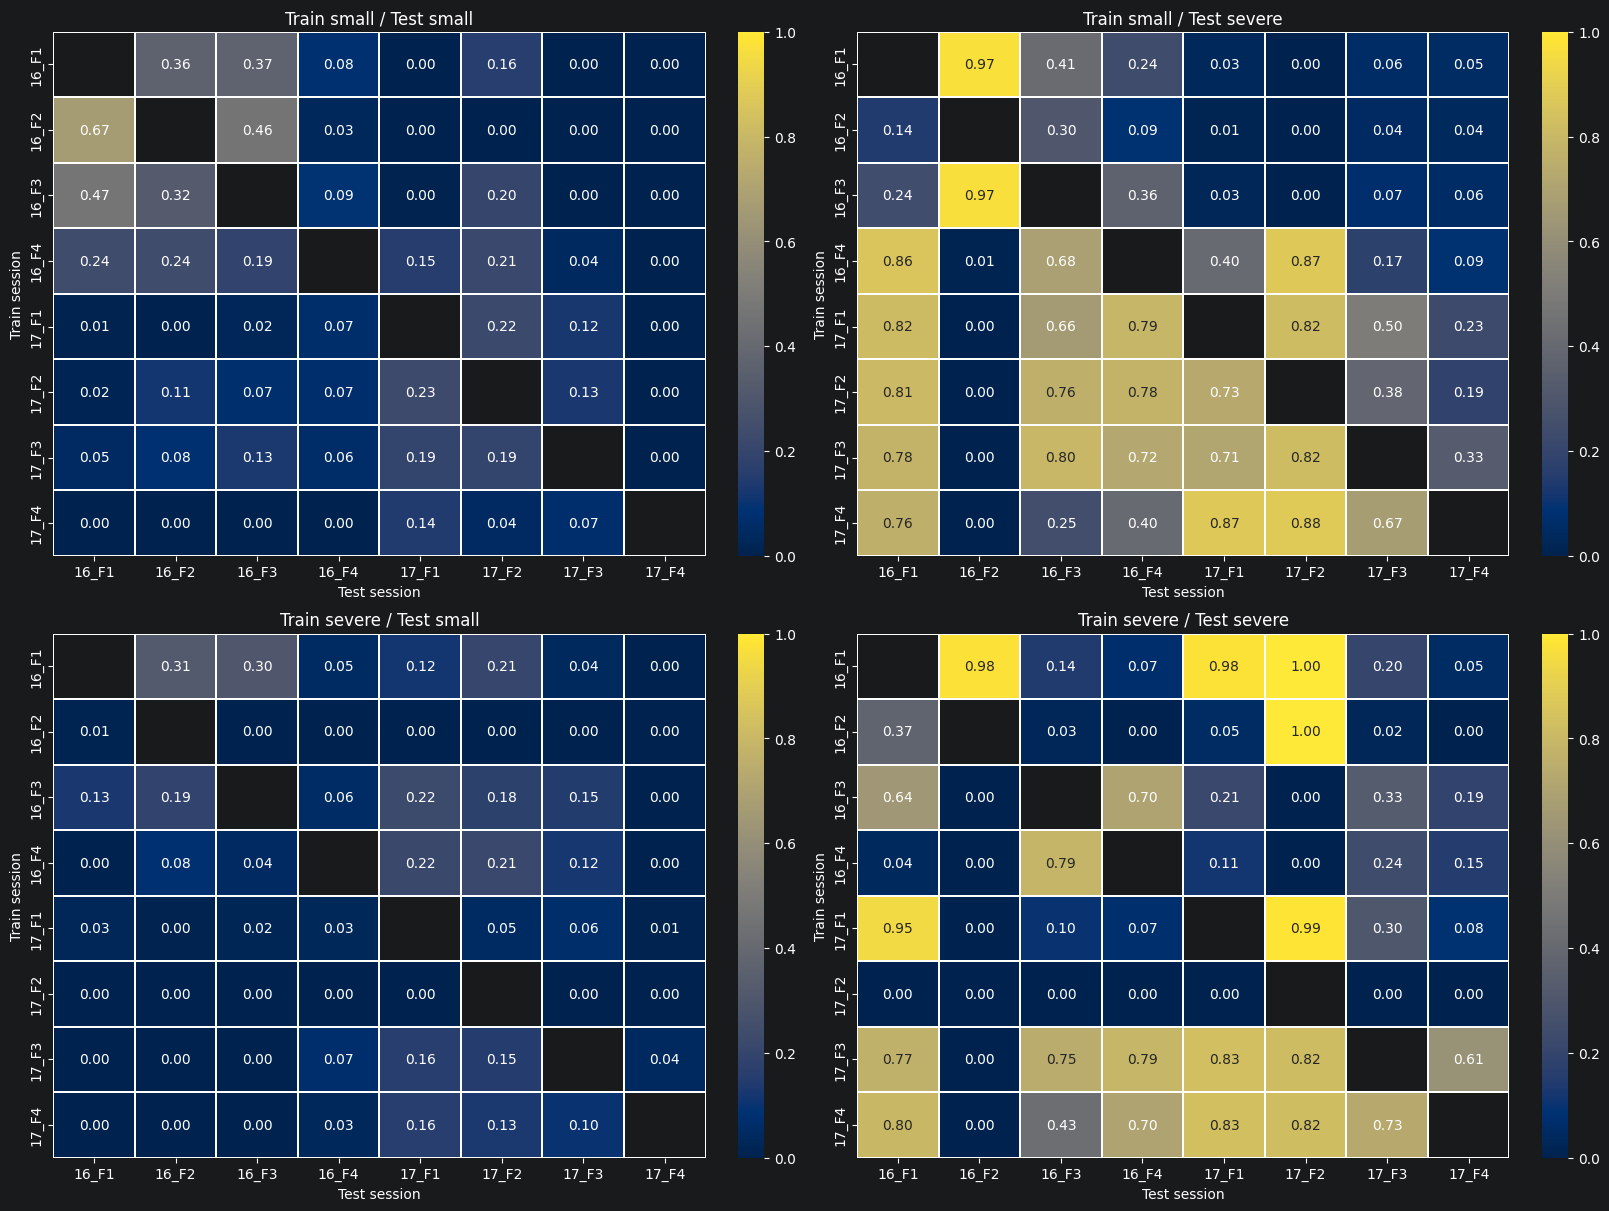

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

combinations = [
    ("small", "small"),
    ("small", "severe"),
    ("severe", "small"),
    ("severe", "severe"),
]

for axis, (train_sev, test_sev) in zip(ax.flatten(), combinations):

    plot_df = results_table[
        (results_table["train_severity"] == train_sev)
        & (results_table["test_severity"] == test_sev)
    ]

    pivot = plot_df.pivot(
        index="train_session",
        columns="test_session",
        values="f1"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="cividis",
        vmin=0,
        vmax=1,
        linewidths=0.3,
        linecolor="white",
        cbar=True,
        ax=axis
    )

    axis.set_title(f"Train {train_sev} / Test {test_sev}")
    axis.set_xlabel("Test session")
    axis.set_ylabel("Train session")

plt.show()